# Tutorial 2: Plotting and CLI options

This notebook expands on Tutorial 1 by plotting the inputs and outputs and by walking through a few additional `floodsr tohr` CLI arguments.


# Using this tutorial

There are three common ways to run this tutorial (i.e., *execution contexts*):
- **command line (CLI)**: proceed by copy/pasting the below commands from your web-browser into your terminal. NOTE for most terminals you'll need to remove the prefix `!` from each command.
- **local notebook (Jupyter)**: Use the <i class="fas fa-download"></i> button to save this notebook as an `.ipynb` file to your local machine (may need to click *save as*) and open it with your local Jupyter kernel. see {ref}`_basic_install_local_notebook` for details.
- **hosted notebook (Colab)**: Use the <i class="fas fa-rocket"></i> button to open this tutorial on Google Colab.


# Install `floodsr`

This tutorial uses the same install flow and the same sample rasters as Tutorial 1. If you have not already installed `floodsr` or downloaded `lowres032.tif` and `hires002_dem.tif`, go back to Tutorial 1 first.

The appropriate installation steps depend on your execution context, which is described in detail in :ref:`_basic_install`.
Here are the basic steps for each:
- **command line (CLI)**: first, ensure pipx is installed and on PATH, then run `pipx install floodsr`. see {ref}`_basic_install_cli` for more details.
- **local notebook (Jupyter)**: same as above. then either follow the additional steps in {ref}`_basic_install_local_notebook` to properly set up your environment, or be lazy and uncomment the below Jupyter cell and run.
- **hosted notebook (Colab)**: uncomment the below colab cell and run. see {ref}`basic_install_google_colab` for details.


In [1]:
# command line (CLI) install. run `pipx install floodsr`


Local notebook (Jupyter) magic install


In [2]:
# %pip install -q floodsr


Hosted notebook (Colab) install


In [3]:
# !python -m pip install -q floodsr


### prove the install

run the below command to confirm the install worked and `floodsr` is on your PATH:


In [4]:
!floodsr --help


[tutorial_2 floodsr] argv= python -m floodsr.cli --help
usage: floodsr [-h] [-v] [-q] [--log-level {DEBUG,INFO,WARNING,ERROR}]
               {models,tohr,doctor} ...

Run FloodSR model, cache, and runtime utility commands.

positional arguments:
  {models,tohr,doctor}
    models              List manifest models or fetch cached model weights.
    tohr                Run one super-resolution pass for a low-res depth
                        raster.
    doctor              Report runtime dependency and provider diagnostics.

options:
  -h, --help            show this help message and exit
  -v, --verbose         Increase logging verbosity (repeatable).
  -q, --quiet           Decrease logging verbosity (repeatable).
  --log-level {DEBUG,INFO,WARNING,ERROR}
                        Explicit log level override.


## Imports

We use `matplotlib` to plot the rasters and `rasterio` to inspect raster metadata.


In [5]:
import logging
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.crs import CRS
from rasterio.warp import Resampling, calculate_default_transform, reproject


## Download the same test data as Tutorial 1

If you already downloaded these files while working through Tutorial 1, this cell will just overwrite them in the current working directory.


In [6]:
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.3/hires002_dem.tif",
    "hires002_dem.tif",
)
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.3/lowres032.tif",
    "lowres032.tif",
)
lowres_fp = Path("lowres032.tif").resolve()
dem_fp = Path("hires002_dem.tif").resolve()
assert lowres_fp.is_file(), f"missing low-res raster\n    {lowres_fp}"
assert dem_fp.is_file(), f"missing DEM raster\n    {dem_fp}"


## Plot the tutorial inputs

We start by plotting the low-resolution flood-depth raster in blue and the DEM tile with a terrain colormap.


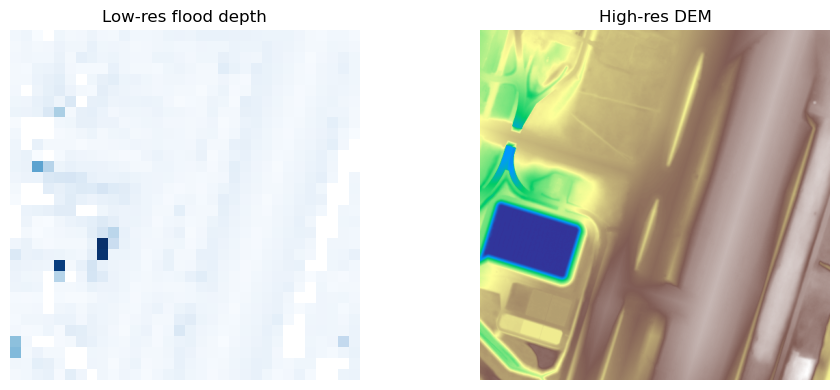

In [7]:
with rasterio.open(lowres_fp) as src:
    lowres_arr = src.read(1).astype(float)
    if src.nodata is not None:
        lowres_arr[lowres_arr == src.nodata] = np.nan

with rasterio.open(dem_fp) as src:
    dem_arr = src.read(1).astype(float)
    if src.nodata is not None:
        dem_arr[dem_arr == src.nodata] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.where(lowres_arr > 0, lowres_arr, np.nan), cmap="Blues")
axes[0].set_title("Low-res flood depth")
axes[0].axis("off")
axes[1].imshow(dem_arr, cmap="terrain")
axes[1].set_title("High-res DEM")
axes[1].axis("off")
fig.tight_layout()


## Probe the CRS of both rasters

A coordinate reference system (CRS) tells raster software how pixel locations map onto real-world coordinates.

Before we trigger a CRS mismatch on purpose, let's inspect the CRS metadata on the original rasters.


In [8]:
with rasterio.open(lowres_fp) as src:
    print(f"{lowres_fp.name}: crs={src.crs} shape={src.shape} res={src.res}")

with rasterio.open(dem_fp) as src:
    print(f"{dem_fp.name}: crs={src.crs} shape={src.shape} res={src.res}")


lowres032.tif: crs=EPSG:3979 shape=(32, 32) res=(32.0, 32.0)
hires002_dem.tif: crs=EPSG:3979 shape=(512, 512) res=(2.0, 2.0)


## Create a CRS mismatch on purpose

To demonstrate `--crs-policy`, we reproject the low-resolution raster to `3978` and save it as a new GeoTIFF.


In [9]:
lowres_3978_fp = Path("lowres032_epsg3978.tif").resolve()
target_crs = CRS.from_epsg(3978)

with rasterio.open(lowres_fp) as src:
    transform, width, height = calculate_default_transform(
        src.crs,
        target_crs,
        src.width,
        src.height,
        *src.bounds,
    )
    profile = src.profile.copy()
    profile.update(crs=target_crs, transform=transform, width=width, height=height)
    with rasterio.open(lowres_3978_fp, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=transform,
            dst_crs=target_crs,
            dst_nodata=src.nodata,
            resampling=Resampling.nearest,
        )

with rasterio.open(lowres_3978_fp) as src:
    print(f"{lowres_3978_fp.name}: crs={src.crs} shape={src.shape} res={src.res}")


lowres032_epsg3978.tif: crs=EPSG:3978 shape=(32, 32) res=(32.0, 32.0)


## Run `tohr` with the mismatched CRS

This command should fail because the low-resolution raster and the DEM no longer share the same CRS.


In [10]:
!floodsr tohr --in lowres032_epsg3978.tif --dem hires002_dem.tif


INFO:__main__:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:__main__:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple
ERROR:__main__:CRS mismatch under --crs-policy strict
    depth=EPSG:3978
    dem=EPSG:3979



## What `--crs-policy` does

`--crs-policy` controls how `floodsr` handles CRS mismatches between the low-resolution depth raster and the DEM. This is necessary because `tohr` needs the rasters to line up on a common projected grid before preprocessing and inference can proceed.

For this example we use `--crs-policy=use-dem`, which tells `floodsr` to treat the DEM CRS as the target CRS and reproject the low-resolution depth raster to match it.


In [11]:
!floodsr tohr --in lowres032_epsg3978.tif --dem hires002_dem.tif --crs-policy=use-dem --out lowres032_epsg3978_use_dem_sr.tif


[tutorial_2 floodsr] argv= python -m floodsr.cli tohr --in lowres032_epsg3978.tif --dem hires002_dem.tif --crs-policy=use-dem --out lowres032_epsg3978_use_dem_sr.tif


INFO:__main__:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:__main__:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple
    depth=EPSG:3978
    dem=EPSG:3979
    target=EPSG:3979
    depth=EPSG:3978
    dem=EPSG:3979
    target=EPSG:3979
INFO:__main__:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-jy0b6dkb/lowres032_epsg3978_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-jy0b6dkb/hires002_dem_platform_dem.tif
output
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lo

/home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_epsg3978_use_dem_sr.tif


INFO:__main__:finished tohr inference in 0.095s; wrote 1,116,817 bytes to
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_epsg3978_use_dem_sr.tif


## Plot the CRS-policy result


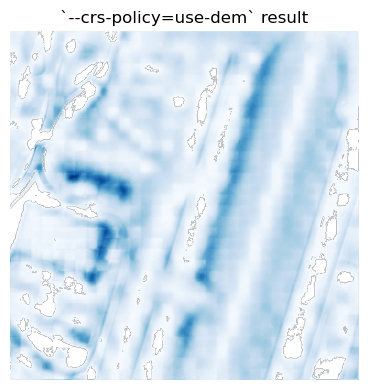

In [12]:
use_dem_fp = Path("lowres032_epsg3978_use_dem_sr.tif").resolve()
with rasterio.open(use_dem_fp) as src:
    use_dem_arr = src.read(1).astype(float)
    if src.nodata is not None:
        use_dem_arr[use_dem_arr == src.nodata] = np.nan

plt.figure(figsize=(5, 4))
plt.imshow(np.where(use_dem_arr > 0, use_dem_arr, np.nan), cmap="Blues")
plt.title("`--crs-policy=use-dem` result")
plt.axis("off")
plt.tight_layout()


## `--min-depth-threshold`

`--min-depth-threshold` sets the minimum predicted depth retained in the output raster. Values below the threshold are written as `0.0`.

This is useful because very small positive predictions can be visually noisy or physically unimportant, and a user may want to tune this threshold to produce a drier or wetter result depending on their use case.


In [13]:
!floodsr tohr --in lowres032.tif --dem hires002_dem.tif --out lowres032_default_sr.tif


[tutorial_2 floodsr] argv= python -m floodsr.cli tohr --in lowres032.tif --dem hires002_dem.tif --out lowres032_default_sr.tif


INFO:__main__:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:__main__:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple


INFO:__main__:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-nichrsuo/lowres032_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-nichrsuo/hires002_dem_platform_dem.tif
output
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_default_sr.tif
INFO:__main__:platform-preprocessed inputs
  depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  dem_hr shape=(512, 512) res=(2.0, 2.0) m/pix
INFO:__main__:model preprocessing complete
INFO:__main__:tohr execution path
  window_method=feather
  execution_path=simple
  model_space_shape=(512, 512)
  raw_output_shape=(512, 512)
INFO:__main__:prepared inputs summary:
  aligned depth_lr shape=

INFO:__main__:running feather tiling over 1x1 grid
  stride_hr=384
  overlap_hr=128
feather pass:   0%|                                   | 0/1 [00:00<?, ?window/s]

final write pass: 100%|██████████████████| 128/128 [00:00<00:00, 9742.16block/s]
INFO:__main__:finished tohr inference in 0.092s; wrote 1,116,817 bytes to
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_default_sr.tif
/home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_default_sr.tif


In [14]:
!floodsr tohr --in lowres032.tif --dem hires002_dem.tif --min-depth-threshold=0.1 --out lowres032_min_depth_01_sr.tif


[tutorial_2 floodsr] argv= python -m floodsr.cli tohr --in lowres032.tif --dem hires002_dem.tif --min-depth-threshold=0.1 --out lowres032_min_depth_01_sr.tif


INFO:__main__:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16


INFO:__main__:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple
INFO:__main__:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-8yhw6sh0/lowres032_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-8yhw6sh0/hires002_dem_platform_dem.tif
output
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_min_depth_01_sr.tif


INFO:__main__:platform-preprocessed inputs
  depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  dem_hr shape=(512, 512) res=(2.0, 2.0) m/pix
INFO:__main__:model preprocessing complete
INFO:__main__:tohr execution path
  window_method=feather
  execution_path=simple
  model_space_shape=(512, 512)
  raw_output_shape=(512, 512)
INFO:__main__:prepared inputs summary:
  aligned depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  aligned dem_hr shape=(512, 512) res=(2.0, 2.0) m/pix
  max_depth=5.0
  dem_pct_clip=95.0
INFO:__main__:window config
  method=feather
  overlap_lr=8
  overlap_hr=128
  tile_size_lr=32
  tile_size_hr=512
INFO:__main__:running feather tiling over 1x1 grid
  stride_hr=384
  overlap_hr=128
feather pass:   0%|                                   | 0/1 [00:00<?, ?window/s]

final write pass: 100%|█████████████████| 128/128 [00:00<00:00, 19725.57block/s]
INFO:__main__:finished tohr inference in 0.075s; wrote 160,772 bytes to
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_min_depth_01_sr.tif
/home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_min_depth_01_sr.tif


## Compare the default threshold and `0.1`

The labels below show the percent of wet pixels in each raster, where `0` is treated as dry.


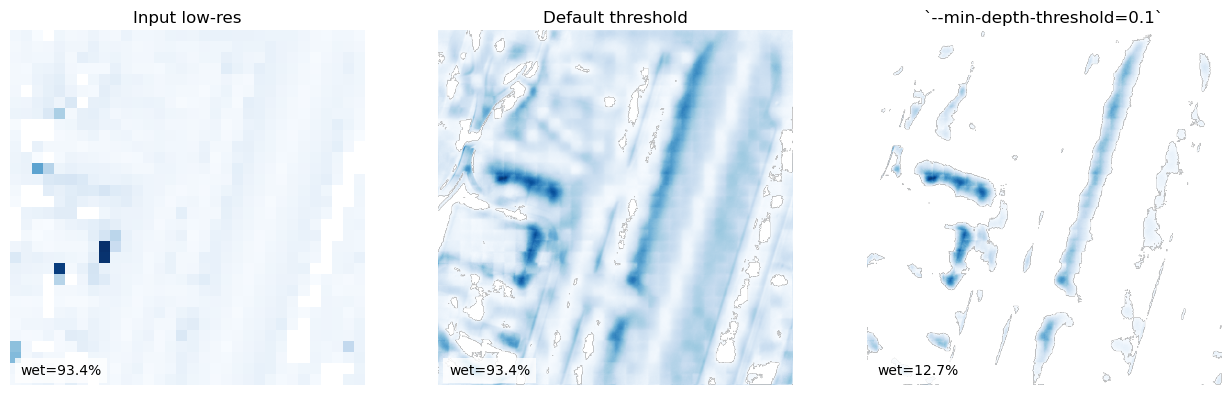

In [15]:
default_fp = Path("lowres032_default_sr.tif").resolve()
threshold_fp = Path("lowres032_min_depth_01_sr.tif").resolve()

with rasterio.open(default_fp) as src:
    default_arr = src.read(1).astype(float)
    if src.nodata is not None:
        default_arr[default_arr == src.nodata] = np.nan

with rasterio.open(threshold_fp) as src:
    threshold_arr = src.read(1).astype(float)
    if src.nodata is not None:
        threshold_arr[threshold_arr == src.nodata] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_l = [
    (axes[0], np.where(lowres_arr > 0, lowres_arr, np.nan), "Input low-res"),
    (axes[1], np.where(default_arr > 0, default_arr, np.nan), "Default threshold"),
    (axes[2], np.where(threshold_arr > 0, threshold_arr, np.nan), "`--min-depth-threshold=0.1`"),
]
for ax, arr, title in plot_l:
    wet_pct = 100.0 * float(np.count_nonzero(np.nan_to_num(arr, nan=0.0) > 0.0)) / float(arr.size)
    ax.imshow(arr, cmap="Blues")
    ax.set_title(title)
    ax.axis("off")
    ax.text(0.03, 0.03, f"wet={wet_pct:.1f}%", transform=ax.transAxes, color="black", fontsize=10, bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})
fig.tight_layout()


## `--window-method=hard`

`--window-method` controls how tiled model outputs are stitched together. The default `feather` mode blends overlapping windows, while `hard` uses non-overlapping tiles with direct writes.

For a small tile like this one there may be little visible difference, but `hard` is still useful to demonstrate because it changes how tiled inference is mosaicked.


In [16]:
!floodsr tohr --in lowres032.tif --dem hires002_dem.tif --window-method=hard --tile-overlap=0 --out lowres032_hard_sr.tif


[tutorial_2 floodsr] argv= python -m floodsr.cli tohr --in lowres032.tif --dem hires002_dem.tif --window-method=hard --tile-overlap=0 --out lowres032_hard_sr.tif


INFO:__main__:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:__main__:tohr path selection
  requested_window_method=hard
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple


INFO:__main__:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-ek7rkzzu/lowres032_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/tmp/floodsr-platform-prep-ek7rkzzu/hires002_dem_platform_dem.tif
output
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_hard_sr.tif
INFO:__main__:platform-preprocessed inputs
  depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  dem_hr shape=(512, 512) res=(2.0, 2.0) m/pix
INFO:__main__:model preprocessing complete
INFO:__main__:tohr execution path
  window_method=hard
  execution_path=simple
  model_space_shape=(512, 512)
  raw_output_shape=(512, 512)
INFO:__main__:prepared inputs summary:
  aligned depth_lr shape=(32, 3

final write pass: 100%|██████████████████| 128/128 [00:00<00:00, 8114.37block/s]


INFO:__main__:finished tohr inference in 0.092s; wrote 1,116,817 bytes to
    /home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_hard_sr.tif
/home/cefect/LS/09_REPOS/04_TOOLS/floodsr_tutorial_2_fix/_cache/notebook_tmp/tutorial_2/run/lowres032_hard_sr.tif


## Plot the hard-window result


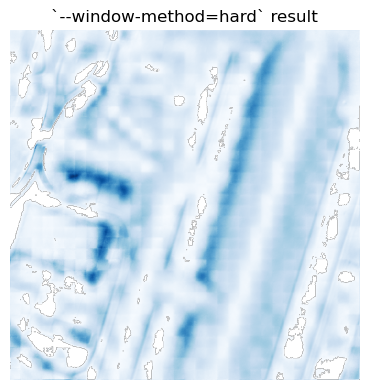

In [17]:
hard_fp = Path("lowres032_hard_sr.tif").resolve()
with rasterio.open(hard_fp) as src:
    hard_arr = src.read(1).astype(float)
    if src.nodata is not None:
        hard_arr[hard_arr == src.nodata] = np.nan

plt.figure(figsize=(5, 4))
plt.imshow(np.where(hard_arr > 0, hard_arr, np.nan), cmap="Blues")
plt.title("`--window-method=hard` result")
plt.axis("off")
plt.tight_layout()


## Next steps

This tutorial introduced plotting, CRS mismatch handling, and a few CLI knobs that affect the output. Continue with Tutorial 3 for the larger-raster workflow.
